# ZDT1 Results

In [ ]:
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_zdt1_front_true
from deap import benchmarks
import multiprocessing
from functools import partial
import matplotlib.pyplot as plt
# 1. Parâmetros (Substituindo as antigas variáveis globais)
IND_SIZE = 30
NPOP = 100
NGEN = 200
NOBJ = 2
NUM_TABLES = int((1 << NOBJ))
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1] * NOBJ

func_zdt1_segura = partial(benchmarks.zdt1)
toolbox = build_toolbox(func_zdt1_segura, IND_SIZE, NPOP, NOBJ)
pareto_real = generate_zdt1_front_true(10000, IND_SIZE)
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    reset = 10
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

Iniciando evolução usando 15 threads...
Evolução concluída!


[[0.7904971769010967, 0.11090091840048744], [0.2120672712596452, 0.539492376545572], [0.8225800973968306, 0.0930379845898558], [0.5150149341015223, 0.28235459027349563], [0.0980291452045301, 0.6869039361401519], [0.539948016768589, 0.2651884481252428], [0.29499122229440355, 0.4568690560330745], [0.7593383095842058, 0.12859979941234478], [0.6964373102622362, 0.16547180379436177], [0.535198025610309, 0.26842770308717334], [0.8327444781511071, 0.08745165708818081], [0.04262550478525884, 0.7935405492953669], [0.245559492311751, 0.5044604028821198], [0.5402072695459658, 0.2650120616323246], [0.6709376739484608, 0.18089214754804062], [0.6225995472688177, 0.2109502251005848], [0.9605450075370142, 0.019926019355164026], [0.9357004186362009, 0.03268390965713752], [0.11902752258136062, 0.6549963441043549], [0.6052846750433624, 0.22199956616762584], [0.8931634079638638, 0.05492677111037381], [0.2087281945163677, 0.5431321914203544], [0.8045516839371016, 0.10303194932199422], [0.2708007915383367, 

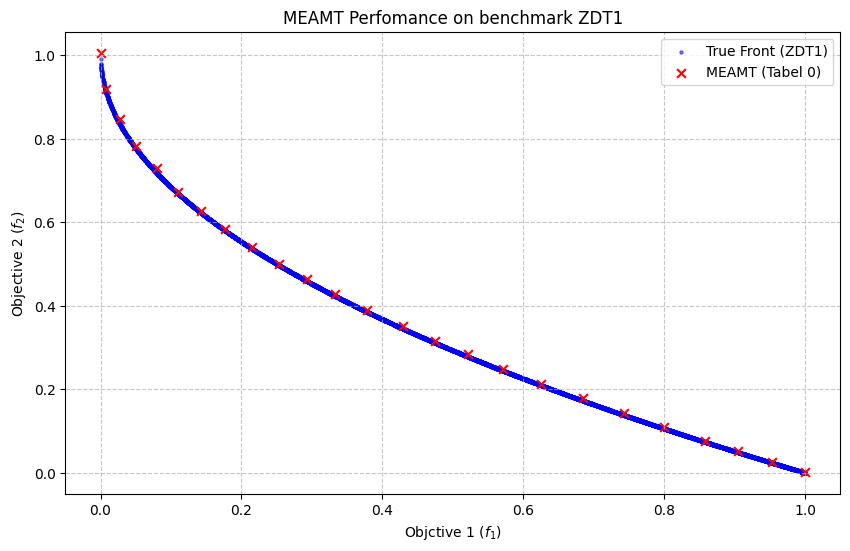

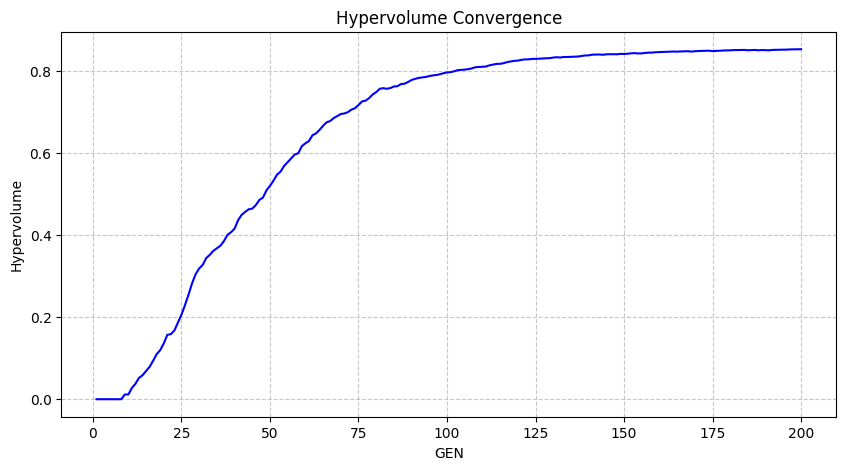

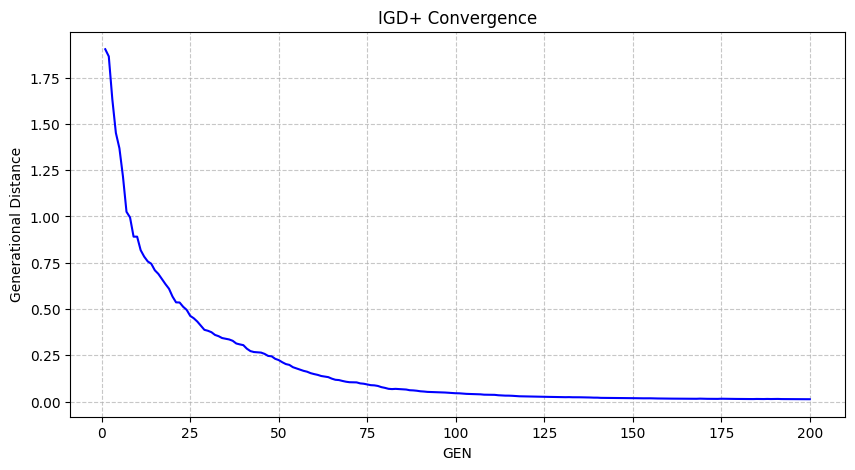

In [4]:
print(pareto_real)
f1_approx = [ind.fitness.values[0] for ind in tabelas[0]]
f2_approx = [ind.fitness.values[1] for ind in tabelas[0]]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT1)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='MEAMT (Tabel 0)')

plt.title("MEAMT Perfomance on benchmark ZDT1")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()